# PPA Exposure Modelling — Step 3
## Seasonal bootstrap: 60-month forward curve

**Goal:** build the vector of monthly forwards $F(0, m)$ for $m \in$ {Jul-26, ..., Jun-31} (60 months), combining:
1. Multiplicative seasonal pattern $s(m)$ calibrated to historical DK1.
2. Levels dictated by the 18 EEX M/Q/Y contracts loaded in Step 2.

**No-arbitrage constraint:** the monthly curve must exactly reproduce the observed M, Q, Y prices when re-aggregated.

**Output:** `data/monthly_forward_curve_dk1_20260604.csv` with 60 rows (delivery_month, forward_eur_mwh), direct input for the Monte Carlo engine in Step 4.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("../data")
SPOT_DAILY_PATH = DATA_DIR / "spot_dk1_2021-01-01_2026-06-04_daily.csv"  # adjust if the filename differs
FORWARDS_PATH = DATA_DIR / "forwards_dk1_eex_20260604.csv"
T0 = pd.Timestamp("2026-06-04")

## 1. Load inputs

In [2]:
spot = pd.read_csv(SPOT_DAILY_PATH, parse_dates=["Date"])
fwd = pd.read_csv(FORWARDS_PATH, parse_dates=["delivery_start", "delivery_end", "trading_day"])

print(f"Daily spot: {len(spot):,} rows, {spot['Date'].min().date()} -> {spot['Date'].max().date()}")
print(f"Forwards: {len(fwd)} contracts")

Daily spot: 1,981 rows, 2021-01-01 -> 2026-06-04
Forwards: 18 contracts


## 2. Computing seasonal factors $s(m)$

**Method**: monthly-to-annual ratio, averaged over complete years.

1. For each (year, month), compute the daily mean of the month.
2. For each year, compute the annual mean.
3. Ratio $r_{y,m} = \bar{P}_{y,m} / \bar{P}_y$.
4. $s_{\text{raw}}(m) = $ mean of ratios $r_{y,m}$ over complete years.
5. Normalise so that $\sum_m d_m \cdot s(m) / \sum_m d_m = 1$ (days-weighted mean = 1).

This produces factors that are robust to level shifts (2022 does not contaminate the seasonal shape).

In [3]:
# Only use complete calendar years to calibrate the seasonal shape (avoids partial-year bias)
spot["Year"] = spot["Date"].dt.year
spot["Month"] = spot["Date"].dt.month

months_per_year = spot.groupby("Year")["Month"].nunique()
complete_years = months_per_year[months_per_year == 12].index.tolist()
print(f"Complete years used to calibrate seasonality: {complete_years}")

spot_complete = spot[spot["Year"].isin(complete_years)].copy()

# Monthly mean per (year, month)
monthly_avg = spot_complete.groupby(["Year", "Month"])["SpotPriceEUR"].mean().rename("MonthAvg")
yearly_avg = spot_complete.groupby("Year")["SpotPriceEUR"].mean().rename("YearAvg")

ratios = monthly_avg.reset_index().merge(yearly_avg.reset_index(), on="Year")
ratios["Ratio"] = ratios["MonthAvg"] / ratios["YearAvg"]

# Average ratios across years for each calendar month
s_raw = ratios.groupby("Month")["Ratio"].mean()

# Normalise so that the days-weighted mean = 1
days_in_month = pd.Series(
    [31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31],
    index=range(1, 13)
)
normalizer = (s_raw * days_in_month).sum() / days_in_month.sum()
seasonal_factors = (s_raw / normalizer).rename("s(m)")

print("\nCalibrated seasonal factors:")
print(seasonal_factors.round(4).to_string())
print(f"\nSanity check: days-weighted mean = {(seasonal_factors * days_in_month).sum() / days_in_month.sum():.6f} (should be ~1)")

Complete years used to calibrate seasonality: [2021, 2022, 2023, 2024, 2025]

Calibrated seasonal factors:
Month
1     0.9340
2     0.9269
3     0.9263
4     0.8328
5     0.7746
6     0.9015
7     0.9617
8     1.1906
9     1.1742
10    0.9391
11    1.1529
12    1.2809

Sanity check: days-weighted mean = 1.000000 (should be ~1)


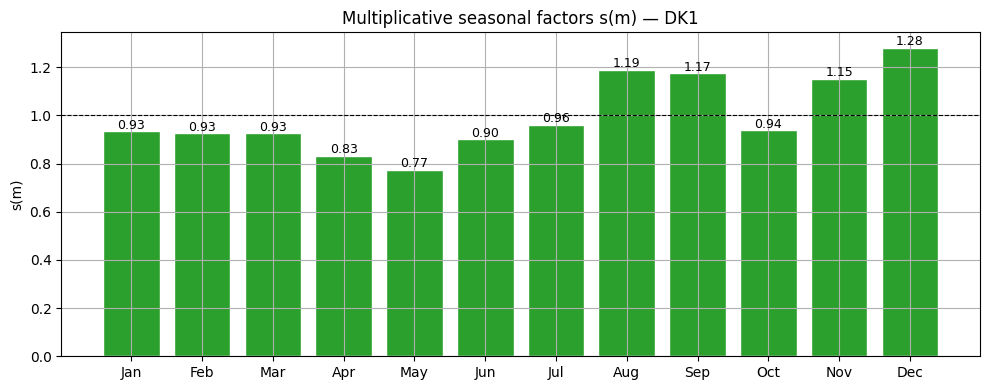

In [4]:
# Visualisation of the factors
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(seasonal_factors.index, seasonal_factors.values, color="#2ca02c", edgecolor="white")
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Multiplicative seasonal factors s(m) — DK1")
ax.set_ylabel("s(m)")
for m, s in seasonal_factors.items():
    ax.text(m, s + 0.01, f"{s:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Building the 60-month skeleton

Target: $m \in$ {Jul-26, Aug-26, ..., Jun-31}. 60 months, first day of the month as index.

In [5]:
# Generate the 60 delivery months, starting the month after t0
target_months = pd.date_range("2026-07-01", periods=60, freq="MS")

# Working table: for each month I store (start, end, days, seasonal factor, forward)
curve = pd.DataFrame({"month_start": target_months})
curve["month_end"] = curve["month_start"] + pd.offsets.MonthEnd(0)
curve["days_in_month"] = (curve["month_end"] - curve["month_start"]).dt.days + 1
curve["s_m"] = curve["month_start"].dt.month.map(seasonal_factors)
curve["forward"] = np.nan
curve["source"] = ""
curve.head(8)

,month_start,month_end,days_in_month,s_m,forward,source
0,2026-07-01,2026-07-31,31,0.961717,NaN,
1,2026-08-01,2026-08-31,31,1.190602,NaN,
2,2026-09-01,2026-09-30,30,1.174202,NaN,
3,2026-10-01,2026-10-31,31,0.939065,NaN,
4,2026-11-01,2026-11-30,30,1.152888,NaN,
5,2026-12-01,2026-12-31,31,1.280933,NaN,
6,2027-01-01,2027-01-31,31,0.933964,NaN,
7,2027-02-01,2027-02-28,28,0.926890,NaN,


## 4. Seasonal disaggregation function with constraint

For a contract $C$ with price $F_C$ and period $[t_{\text{start}}, t_{\text{end}}]$, identify the covered months. If part is already set (by more granular contracts), apply:

$$\text{level}_C = \frac{F_C \cdot D_C - \sum_{m \in \text{set}} F(0,m) \cdot d_m}{\sum_{m \in \text{unset}} s(m) \cdot d_m}$$

$$F(0, m) = \text{level}_C \cdot s(m) \quad \forall m \in \text{unset}$$

In [6]:
def apply_contract(curve: pd.DataFrame, contract_row: pd.Series, source_label: str) -> None:
    """Set forwards for the unassigned months falling within the contract, in-place."""
    F_C = contract_row["settlement_price_eur_mwh"]
    period_start = contract_row["delivery_start"]
    period_end = contract_row["delivery_end"]

    # Months covered by this contract (that are also in the target)
    mask = (curve["month_start"] >= period_start) & (curve["month_end"] <= period_end)
    if not mask.any():
        # Contract does not touch any target month — skip
        return

    covered = curve[mask]
    D_C = covered["days_in_month"].sum()

    set_mask = mask & curve["forward"].notna()
    unset_mask = mask & curve["forward"].isna()

    if not unset_mask.any():
        # Contract fully covered by more granular ones; nothing to set (will be used as a check later)
        return

    S_set = (curve.loc[set_mask, "forward"] * curve.loc[set_mask, "days_in_month"]).sum()
    weighted_s_unset = (curve.loc[unset_mask, "s_m"] * curve.loc[unset_mask, "days_in_month"]).sum()

    level = (F_C * D_C - S_set) / weighted_s_unset
    curve.loc[unset_mask, "forward"] = level * curve.loc[unset_mask, "s_m"]
    curve.loc[unset_mask, "source"] = source_label

## 5. Apply contracts in cascade: M → Q → Y

In [7]:
# Step A: Monthlies (most granular, first)
for _, row in fwd[fwd["contract_type"] == "M"].iterrows():
    apply_contract(curve, row, source_label=f"M:{row['delivery_label']}")

print("After applying Monthlies:")
print(curve[curve["forward"].notna()][["month_start", "forward", "source"]])
print(f"\nMonths set: {curve['forward'].notna().sum()} / 60")

After applying Monthlies:
  month_start  forward    source
0  2026-07-01   102.45  M:Jul-26
1  2026-08-01    98.03  M:Aug-26
2  2026-09-01   104.27  M:Sep-26
3  2026-10-01    97.75  M:Oct-26
4  2026-11-01   114.79  M:Nov-26
5  2026-12-01   119.54  M:Dec-26

Months set: 6 / 60


In [8]:
# Step B: Quarterlies
for _, row in fwd[fwd["contract_type"] == "Q"].iterrows():
    apply_contract(curve, row, source_label=f"Q:{row['delivery_label']}")

print(f"After applying Quarterlies: {curve['forward'].notna().sum()} / 60 months set")
curve[curve["forward"].notna()].tail(10)

After applying Quarterlies: 21 / 60 months set


,month_start,month_end,days_in_month,s_m,forward,source
11,2027-06-01,2027-06-30,30,0.901546,83.861344,Q:Q2-27
12,2027-07-01,2027-07-31,31,0.961717,71.148326,Q:Q3-27
13,2027-08-01,2027-08-31,31,1.190602,88.081313,Q:Q3-27
14,2027-09-01,2027-09-30,30,1.174202,86.868039,Q:Q3-27
15,2027-10-01,2027-10-31,31,0.939065,72.594759,Q:Q4-27
16,2027-11-01,2027-11-30,30,1.152888,89.124367,Q:Q4-27
17,2027-12-01,2027-12-31,31,1.280933,99.022951,Q:Q4-27
18,2028-01-01,2028-01-31,31,0.933964,74.045559,Q:Q1-28
19,2028-02-01,2028-02-29,29,0.926890,73.484768,Q:Q1-28
20,2028-03-01,2028-03-31,31,0.926305,73.438368,Q:Q1-28


In [9]:
# Step C: Yearlies
for _, row in fwd[fwd["contract_type"] == "Y"].iterrows():
    apply_contract(curve, row, source_label=f"Y:{row['delivery_label']}")

print(f"After applying Yearlies: {curve['forward'].notna().sum()} / 60 months set")
assert curve["forward"].notna().all(), "Unassigned months remain"
print("\n✓ Monthly curve complete")

After applying Yearlies: 60 / 60 months set

✓ Monthly curve complete


## 6. Visualisation of the result

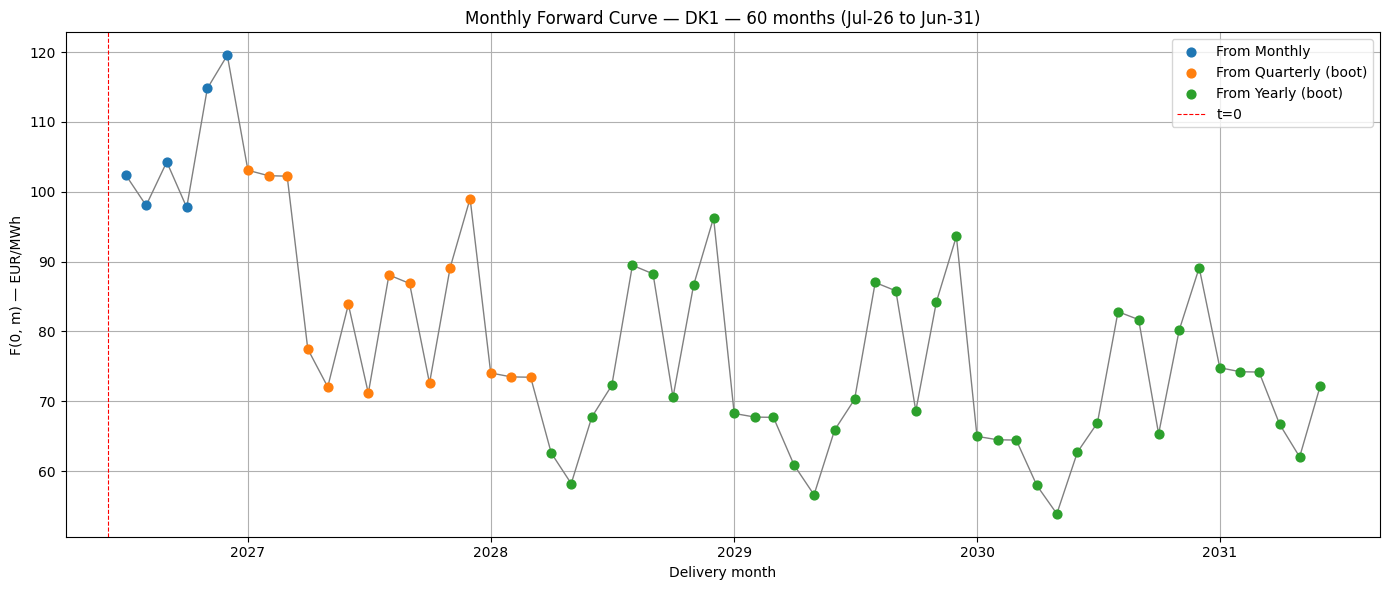

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

# Colour by source for each month
color_by_source = {"M": "#1f77b4", "Q": "#ff7f0e", "Y": "#2ca02c"}
curve["source_type"] = curve["source"].str[0]

for stype, color in color_by_source.items():
    subset = curve[curve["source_type"] == stype]
    label = {"M": "From Monthly", "Q": "From Quarterly (boot)", "Y": "From Yearly (boot)"}[stype]
    ax.scatter(subset["month_start"], subset["forward"], color=color, s=40, label=label, zorder=3)

ax.plot(curve["month_start"], curve["forward"], color="gray", linewidth=1, zorder=2)
ax.axvline(T0, color="red", linestyle="--", linewidth=0.8, label="t=0")
ax.set_title("Monthly Forward Curve — DK1 — 60 months (Jul-26 to Jun-31)")
ax.set_xlabel("Delivery month")
ax.set_ylabel("F(0, m) — EUR/MWh")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Validation: the monthly curve reproduces the M/Q/Y settlements

By construction, the days-weighted averages must coincide exactly with the observed settlements. Any deviation > 0.01 EUR/MWh would indicate a bug.

In [11]:
def check_contract(curve: pd.DataFrame, contract_row: pd.Series) -> dict:
    mask = (curve["month_start"] >= contract_row["delivery_start"]) & (curve["month_end"] <= contract_row["delivery_end"])
    if not mask.any():
        return None
    covered = curve[mask]
    implied = (covered["forward"] * covered["days_in_month"]).sum() / covered["days_in_month"].sum()
    return {
        "label": contract_row["delivery_label"],
        "type": contract_row["contract_type"],
        "market": contract_row["settlement_price_eur_mwh"],
        "implied": implied,
        "diff": implied - contract_row["settlement_price_eur_mwh"],
        "months_covered": mask.sum(),
    }

checks = [c for c in (check_contract(curve, row) for _, row in fwd.iterrows()) if c is not None]
check_df = pd.DataFrame(checks)
check_df["abs_diff"] = check_df["diff"].abs()

print(check_df.round(4).to_string(index=False))
print(f"\nMax abs diff: {check_df['abs_diff'].max():.6f} EUR/MWh")
assert check_df["abs_diff"].max() < 0.01, "Reconciliation failed — bug in the disaggregation"
print("✓ All contracts reproduced with error < 0.01 EUR/MWh")

 label type  market  implied    diff  months_covered  abs_diff
Jul-26    M  102.45 102.4500  0.0000               1    0.0000
Aug-26    M   98.03  98.0300 -0.0000               1    0.0000
Sep-26    M  104.27 104.2700  0.0000               1    0.0000
Oct-26    M   97.75  97.7500  0.0000               1    0.0000
Nov-26    M  114.79 114.7900 -0.0000               1    0.0000
Dec-26    M  119.54 119.5400  0.0000               1    0.0000
 Q3-26    Q  101.55 101.5541  0.0041               3    0.0041
 Q4-26    Q  110.64 110.6488  0.0088               3    0.0088
 Q1-27    Q  102.54 102.5400  0.0000               3    0.0000
 Q2-27    Q   77.73  77.7300 -0.0000               3    0.0000
 Q3-27    Q   81.98  81.9800  0.0000               3    0.0000
 Q4-27    Q   86.89  86.8900  0.0000               3    0.0000
 Q1-28    Q   73.66  73.6600  0.0000               3    0.0000
Cal-27    Y   87.23  87.2276 -0.0024              12    0.0024
Cal-28    Y   76.09  76.0900  0.0000              12   

## 8. Save the monthly curve

In [12]:
output_path = DATA_DIR / "monthly_forward_curve_dk1_20260604.csv"

out = curve[["month_start", "forward", "source"]].copy()
out.columns = ["delivery_month", "forward_eur_mwh", "source_contract"]
out["delivery_month"] = out["delivery_month"].dt.strftime("%Y-%m")
out.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"  {len(out)} months, dates {out['delivery_month'].iloc[0]} -> {out['delivery_month'].iloc[-1]}")
out.head(12)

Saved: ..\data\monthly_forward_curve_dk1_20260604.csv
  60 months, dates 2026-07 -> 2031-06


,delivery_month,forward_eur_mwh,source_contract
0,2026-07,102.450000,M:Jul-26
1,2026-08,98.030000,M:Aug-26
2,2026-09,104.270000,M:Sep-26
3,2026-10,97.750000,M:Oct-26
4,2026-11,114.790000,M:Nov-26
5,2026-12,119.540000,M:Dec-26
6,2027-01,103.074001,Q:Q1-27
7,2027-02,102.293360,Q:Q1-27
8,2027-03,102.228771,Q:Q1-27
9,2027-04,77.468664,Q:Q2-27


## 9. Conclusions for the technical document

**Methodology (Forward Curve Construction):**

> The monthly forward curve is constructed via a hierarchical seasonal bootstrap. Multiplicative monthly seasonal factors s(m) are first calibrated from historical DK1 daily prices over complete calendar years 2021-2025, using the ratio of monthly mean to annual mean averaged across years, normalised so that the days-weighted mean equals 1. The monthly curve is then built by processing observed EEX contracts in order of granularity (Monthly → Quarterly → Yearly): for each contract, months not yet assigned by more granular contracts are imputed with $F(0,m) = \text{level}_C \cdot s(m)$, where $\text{level}_C$ is chosen such that the days-weighted average of monthly forwards over the contract period exactly equals the observed settlement. This construction guarantees by design that the resulting monthly curve reproduces all M/Q/Y EEX settlements (reconciliation error < 0.01 EUR/MWh).

**Properties verified:**
- 60 months built (Jul-26 to Jun-31).
- Reconciliation: all 18 contracts reproduced within 0.01 EUR/MWh.
- Seasonality consistent with both historical pattern and observed Q1-27/Q4-27 vs Q2-27/Q3-27.

**Limitations:**
- Seasonal shape calibrated to 2021-2025; assumes seasonal pattern stable into 2026-2031 (challenged by growing renewable penetration which may flatten seasonality over time).
- Long-end months (Jan-31 to Jun-31) anchored only to Cal-31, with low open interest — settlement reliability degrades.

**Next step (Step 4): calibrate the Schwartz one-factor model to the DK1 historical series.**